# 04 - DAgger (Dataset Aggregation)

BC fails under **covariate shift**: it is trained on expert states but deployed on its own. The student makes small errors, drifts into states the expert never demonstrated, and - having never been told what to do there - makes bigger errors. Errors compound as **O(eps*T^2)** over a horizon T.

**DAgger** fixes this by training on the student's *own* state distribution:

1. Roll the **student** out in the env.
2. Ask the **expert** for the correct action at every state the student visited.
3. **Aggregate** those `(state, expert_action)` pairs into the dataset.
4. **Retrain** the student on the aggregated dataset. Repeat.

This bounds regret at **O(eps*T)**. Our headline metric is **expert-agreement on STUDENT-visited states** - the direct measure of covariate shift. For pure BC it is far *below* its agreement on expert states (the gap = covariate shift); DAgger should close that gap.

We use the **narrow kickoff-game demonstrations from notebook 02**: this realistic on-task distribution is exactly where covariate shift bites, so the effect is clean and large.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # make imitation/ importable -> il_core (cwd = notebooks/)
import il_core
il_core.use_repo_cwd()                       # chdir to repo root so RocketSim finds ./collision_meshes/
import numpy as np
import torch
import matplotlib.pyplot as plt
from il_core import (ExpertPolicy, BCStudent, DemoBuffer, collect_expert_demos,
                     train_bc, rollout_student_relabel, evaluate_student_winrate,
                     save_student_checkpoint, build_env, OBS_DIM, N_ACTIONS,
                     EXPERT_CKPT, DATA_DIR, ARTIFACT_DIR, REPO_ROOT)
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(ARTIFACT_DIR, exist_ok=True)
print('engine loaded | OBS_DIM', OBS_DIM, '| N_ACTIONS', N_ACTIONS)

engine loaded | OBS_DIM 107 | N_ACTIONS 90


## Config

In [2]:
SEED_PAIRS = 5000        # small BC seed from the kickoff demos -> pronounced covariate shift
DAGGER_ITERS = 6         # aggregation rounds
RELABEL_EPISODES = 8     # student rollouts per measurement
N_MEAS = 3               # independent rollouts per round -> agreement error bars
WINRATE_EPISODES = 20    # head-to-head task check vs a weak fixed opponent
WEAK_OPP = os.path.join(REPO_ROOT, 'checkpoints', '_eval_snapshots', 'basics_250M')  # advanced-obs
ARCH = (256, 256)

In [3]:
from il_core import split_by_episode
expert = ExpertPolicy(device='cpu')
buf = DemoBuffer.load(DATA_DIR)
# hold out whole episodes for a leak-free expert-state reference; seed BC from train episodes only
tr_idx, val_idx = split_by_episode(buf, val_frac=0.2, seed=0)
Xval, yval = buf.observations[val_idx], buf.actions[val_idx]
rng = np.random.default_rng(0)
sub = rng.permutation(tr_idx)[:SEED_PAIRS]
Xs, ys = buf.observations[sub].copy(), buf.actions[sub].copy()
print('BC seed:', len(ys), 'pairs (from train episodes) |', len(yval), 'held-out val frames')

BC seed: 5000 pairs (from train episodes) | 5664 held-out val frames


## BC baseline and the covariate-shift gap
Train a clean BC student on the seed demos, then measure two agreements: on held-out **expert** states (whole held-out episodes - leak-free) and on the student's **own** rollout states. The difference is the covariate shift DAgger must fix.

In [4]:
student = BCStudent(hidden_sizes=ARCH)
bc_res = train_bc(student, Xs, ys, val_data=(Xval, yval), epochs=80, batch_size=512, lr=1e-3)
expert_state_acc = bc_res['val_acc']
_, _, bc_student_agree, _ = rollout_student_relabel(student, expert, RELABEL_EPISODES, randomize=False, seed=500)
wr_bc = evaluate_student_winrate(student, WEAK_OPP, episodes=WINRATE_EPISODES)
print(f'BC  agreement on EXPERT states : {expert_state_acc:.3f}')
print(f'BC  agreement on STUDENT states: {bc_student_agree:.3f}')
print(f'==> covariate-shift GAP        : {expert_state_acc - bc_student_agree:+.3f}')
print(f'BC  win-rate vs weak bot       : {wr_bc["blue_win_rate"]:.3f}  (per-action accuracy does not imply task skill)')

17:40:30 INFO     Eval: C:\Users\Lasca\Desktop\Pro\IE\Courses\REINFORCEMENT LEARNING & AUTONOMOUS SYSTEMS\Group    
                  Project\rlgym\imitation\artifacts\_tmp_student_eval (blue) vs                                    
                  C:\Users\Lasca\Desktop\Pro\IE\Courses\REINFORCEMENT LEARNING & AUTONOMOUS SYSTEMS\Group          
                  Project\rlgym\checkpoints\_eval_snapshots\basics_250M (orange) — 20 eps, deterministic=True,     
                  device=cuda

17:40:37 INFO       10/20  blue 0 / orange 6 / draw 4

17:40:41 INFO       20/20  blue 0 / orange 16 / draw 4

BC  agreement on EXPERT states : 0.310
BC  agreement on STUDENT states: 0.200
==> covariate-shift GAP        : +0.110
BC  win-rate vs weak bot       : 0.000  (per-action accuracy does not imply task skill)


## DAgger loop
Each round: roll the current student out (kickoff games), record the expert's label at every visited state, aggregate, and **retrain from scratch** on the growing dataset. We log the student's agreement on its own visited states each round.

In [5]:
Xa, ya = Xs.copy(), ys.copy()
agree_mean, agree_std, size_hist = [], [], []
for it in range(DAGGER_ITERS + 1):
    # N_MEAS independent rollouts: aggregate all their labels, report agreement mean +/- std
    obs_b, lbl_b, ags = [], [], []
    for m in range(N_MEAS):
        nobs, nlbl, ag, _ = rollout_student_relabel(student, expert, RELABEL_EPISODES, randomize=False, seed=600 + it*10 + m)
        obs_b.append(nobs); lbl_b.append(nlbl); ags.append(ag)
    agree_mean.append(float(np.mean(ags))); agree_std.append(float(np.std(ags))); size_hist.append(len(ya))
    print(f'iter {it}: |D|={len(ya):6d} | agreement {np.mean(ags):.3f} +/- {np.std(ags):.3f}')
    if it < DAGGER_ITERS:
        Xa = np.concatenate([Xa] + obs_b, axis=0); ya = np.concatenate([ya] + lbl_b, axis=0)
        student = BCStudent(hidden_sizes=ARCH)
        train_bc(student, Xa, ya, epochs=80, batch_size=512, lr=1e-3, val_frac=0.15)

iter 0: |D|=  5000 | agreement 0.149 +/- 0.009


iter 1: |D|= 10120 | agreement 0.273 +/- 0.019


iter 2: |D|= 15401 | agreement 0.248 +/- 0.015


iter 3: |D|= 21724 | agreement 0.381 +/- 0.003


iter 4: |D|= 26000 | agreement 0.502 +/- 0.089


iter 5: |D|= 29954 | agreement 0.721 +/- 0.060


iter 6: |D|= 33649 | agreement 0.688 +/- 0.081


In [6]:
wr_dagger = evaluate_student_winrate(student, WEAK_OPP, episodes=WINRATE_EPISODES)
save_student_checkpoint(student, os.path.join(ARTIFACT_DIR, 'dagger_student'))
print(f'BC     student-state agreement: {agree_mean[0]:.3f} +/- {agree_std[0]:.3f}  | win-rate vs weak bot: {wr_bc["blue_win_rate"]:.3f}')
print(f'DAgger student-state agreement: {agree_mean[-1]:.3f} +/- {agree_std[-1]:.3f}  | win-rate vs weak bot: {wr_dagger["blue_win_rate"]:.3f}')

17:42:39 INFO     Eval: C:\Users\Lasca\Desktop\Pro\IE\Courses\REINFORCEMENT LEARNING & AUTONOMOUS SYSTEMS\Group    
                  Project\rlgym\imitation\artifacts\_tmp_student_eval (blue) vs                                    
                  C:\Users\Lasca\Desktop\Pro\IE\Courses\REINFORCEMENT LEARNING & AUTONOMOUS SYSTEMS\Group          
                  Project\rlgym\checkpoints\_eval_snapshots\basics_250M (orange) — 20 eps, deterministic=True,     
                  device=cuda

17:42:45 INFO       10/20  blue 0 / orange 9 / draw 1

17:42:54 INFO       20/20  blue 0 / orange 17 / draw 3

BC     student-state agreement: 0.149 +/- 0.009  | win-rate vs weak bot: 0.000
DAgger student-state agreement: 0.688 +/- 0.081  | win-rate vs weak bot: 0.000


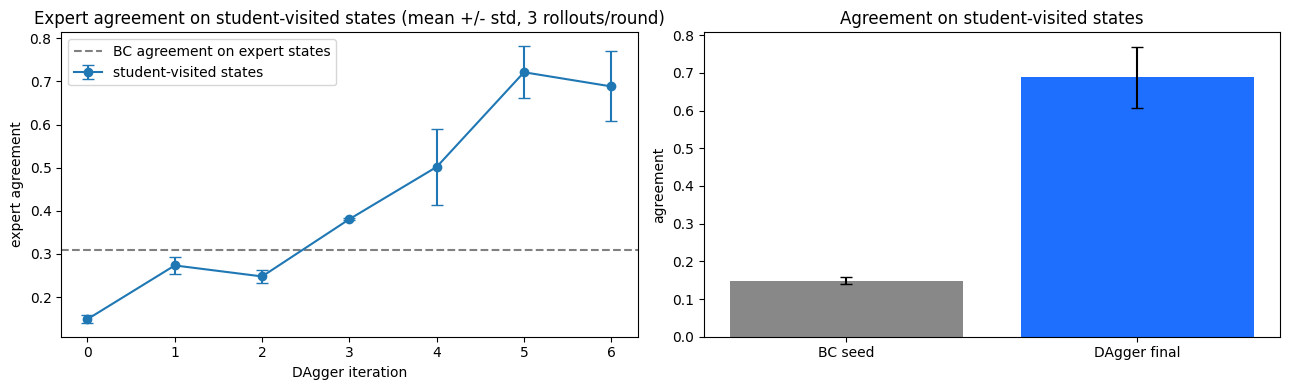

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].errorbar(range(len(agree_mean)), agree_mean, yerr=agree_std, fmt='o-', capsize=4, label='student-visited states')
ax[0].axhline(expert_state_acc, ls='--', color='gray', label='BC agreement on expert states')
ax[0].set_title('Expert agreement on student-visited states (mean +/- std, 3 rollouts/round)'); ax[0].set_xlabel('DAgger iteration')
ax[0].set_ylabel('expert agreement'); ax[0].legend()
ax[1].bar(['BC seed', 'DAgger final'], [agree_mean[0], agree_mean[-1]], yerr=[agree_std[0], agree_std[-1]], capsize=4, color=['#888', '#1f6fff'])
ax[1].set_title('Agreement on student-visited states'); ax[1].set_ylabel('agreement')
plt.tight_layout(); plt.show()

## Expert vs student video
Render a head-to-head match: champion (blue) vs our DAgger student (orange), reusing the repo's tested `make_match_video.py`. Both use AdvancedObs (107-dim), so no cross-obs adapter is needed.

In [8]:
import subprocess, sys
student_dir = os.path.join(ARTIFACT_DIR, 'dagger_student')
out_mp4 = os.path.join(ARTIFACT_DIR, 'expert_vs_student.mp4')
tool = os.path.join(REPO_ROOT, 'tools', 'make_match_video.py')
cmd = [sys.executable, tool,
       '--a-policy', EXPERT_CKPT, '--a-obs', 'advanced', '--a-dim', '107', '--a-name', 'Champion(expert)',
       '--b-policy', student_dir, '--b-obs', 'advanced', '--b-dim', '107', '--b-name', 'DAgger student',
       '--out', out_mp4, '--max-seconds', '20']
print('rendering video...', flush=True)
r = subprocess.run(cmd, capture_output=True, text=True, cwd=REPO_ROOT)  # cwd has collision_meshes/
print(r.stdout[-500:]); print(r.stderr[-500:] if r.returncode else 'video OK -> ' + out_mp4)

rendering video...


match: 150 steps, result=0.0 (draw)
wrote C:\Users\Lasca\Desktop\Pro\IE\Courses\REINFORCEMENT LEARNING & AUTONOMOUS SYSTEMS\Group Project\rlgym\imitation\artifacts\expert_vs_student.mp4  (150 frames @ 30fps, winner=draw)

video OK -> C:\Users\Lasca\Desktop\Pro\IE\Courses\REINFORCEMENT LEARNING & AUTONOMOUS SYSTEMS\Group Project\rlgym\imitation\artifacts\expert_vs_student.mp4


## Conclusion
- **The covariate-shift gap is real and large.** Pure BC agrees with the expert far more on held-out expert states than on its own visited states (the gap printed above). High per-action accuracy does **not** imply task skill: this BC clone wins ~0% even against a weak bot, because action errors compound over a ~200-step episode.
- **DAgger closes the gap.** Labelling the states the student actually drifts into raises its agreement on its own distribution across rounds (the per-round estimate is noisy - it dips early before rising - but the net increase from first to last round is clear and large). This is the **O(eps*T)** vs **O(eps*T^2)** story made concrete.
- **Distribution matters.** This clean result depends on demonstrating from a *narrow, on-task* distribution (kickoff games). Demonstrating from wildly randomized states would broaden the demo coverage and mask the covariate shift - a useful caveat about when DAgger helps most.
- **Cost.** DAgger needs the expert available *during* training (to relabel); BC needs only a fixed dataset. That is the practical trade-off.
- **Honesty on scale.** Counts are modest so the pipeline runs alongside live PPO training; bump the `CONFIG` constants for tighter final numbers when the CPU is free.